In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, HistGradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
df = pd.read_csv('phishing.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [4]:
df['class'] = df['class'].replace(-1, 0)


if 'Index' in df.columns:
    df = df.drop('Index', axis=1)

print('Class balance:')
print(df['class'].value_counts())
print(f'\nNull values: {df.isnull().sum().sum()}')

Class balance:
class
1    6157
0    4897
Name: count, dtype: int64

Null values: 0


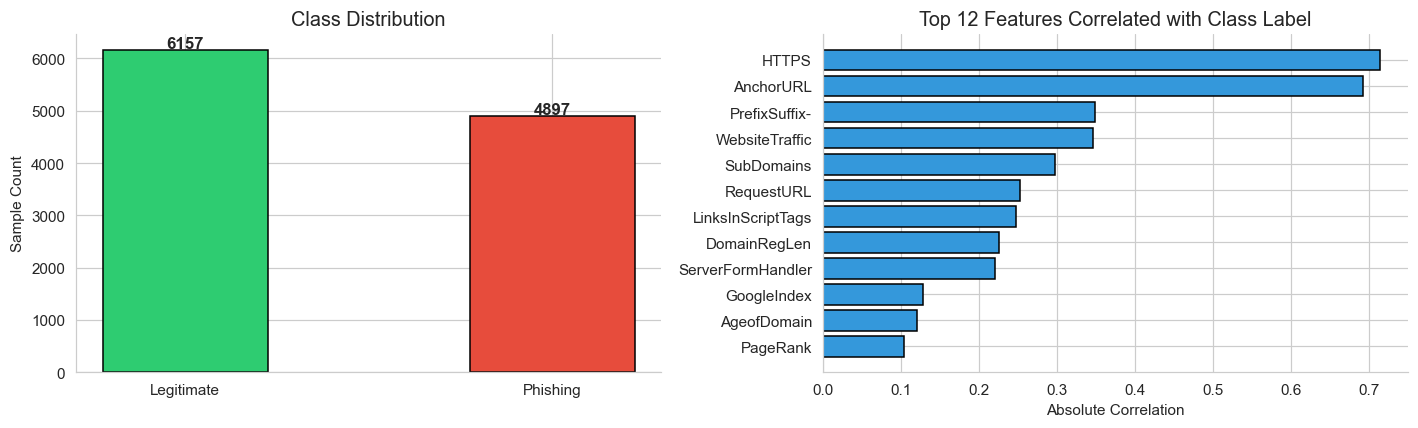

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['class'].value_counts()
axes[0].bar(['Legitimate', 'Phishing'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.45)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Sample Count')

corr_target = df.corr()['class'].abs().drop('class').sort_values(ascending=False).head(12)
axes[1].barh(corr_target.index[::-1], corr_target.values[::-1],
             color='#3498db', edgecolor='black')
axes[1].set_title('Top 12 Features Correlated with Class Label', fontsize=13)
axes[1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

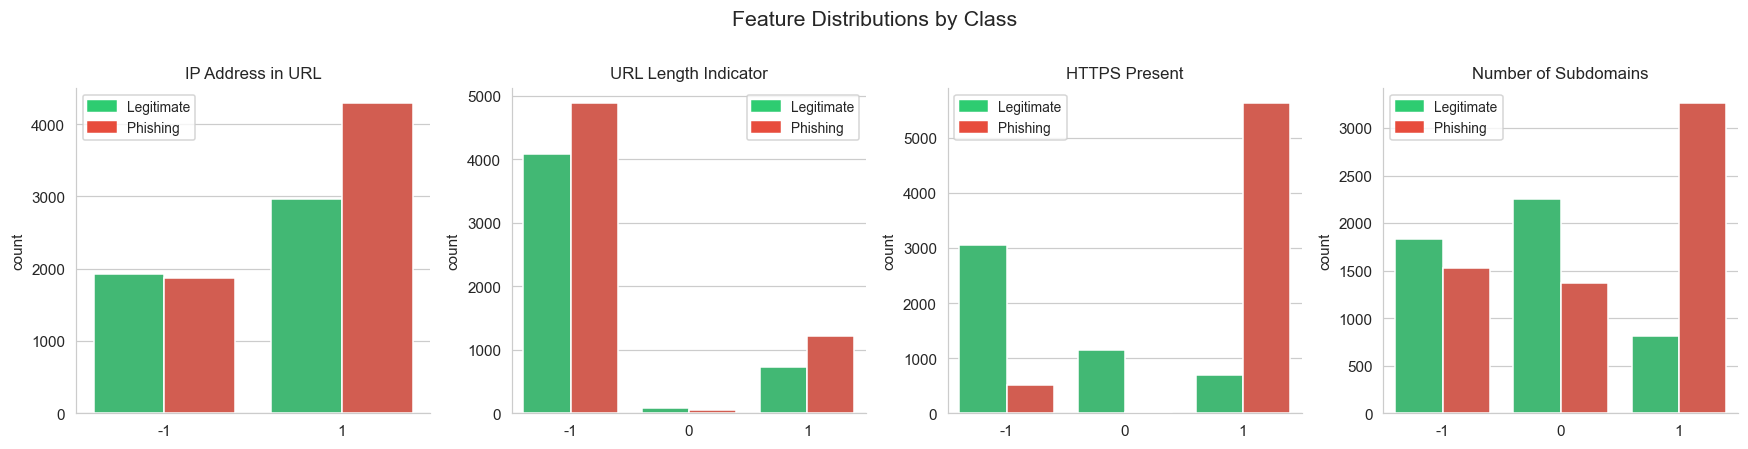

In [6]:
available_features = df.columns.tolist()
candidates = ['UsingIP', 'LongURL', 'HTTPS', 'SubDomains']
plot_features = [f for f in candidates if f in available_features]

if len(plot_features) < 2:
    plot_features = [c for c in available_features if c != 'class'][:4]

titles_map = {
    'UsingIP': 'IP Address in URL',
    'LongURL': 'URL Length Indicator',
    'HTTPS':   'HTTPS Present',
    'SubDomains': 'Number of Subdomains'
}

fig, axes = plt.subplots(1, len(plot_features), figsize=(4 * len(plot_features), 4))
if len(plot_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, plot_features):
    sns.countplot(x=feat, hue='class', data=df, ax=ax,
                  palette={0: '#2ecc71', 1: '#e74c3c'})
    ax.set_title(titles_map.get(feat, feat), fontsize=11)
    ax.set_xlabel('')
    handles = [mpatches.Patch(color='#2ecc71', label='Legitimate'),
               mpatches.Patch(color='#e74c3c', label='Phishing')]
    ax.legend(handles=handles, fontsize=9)

plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

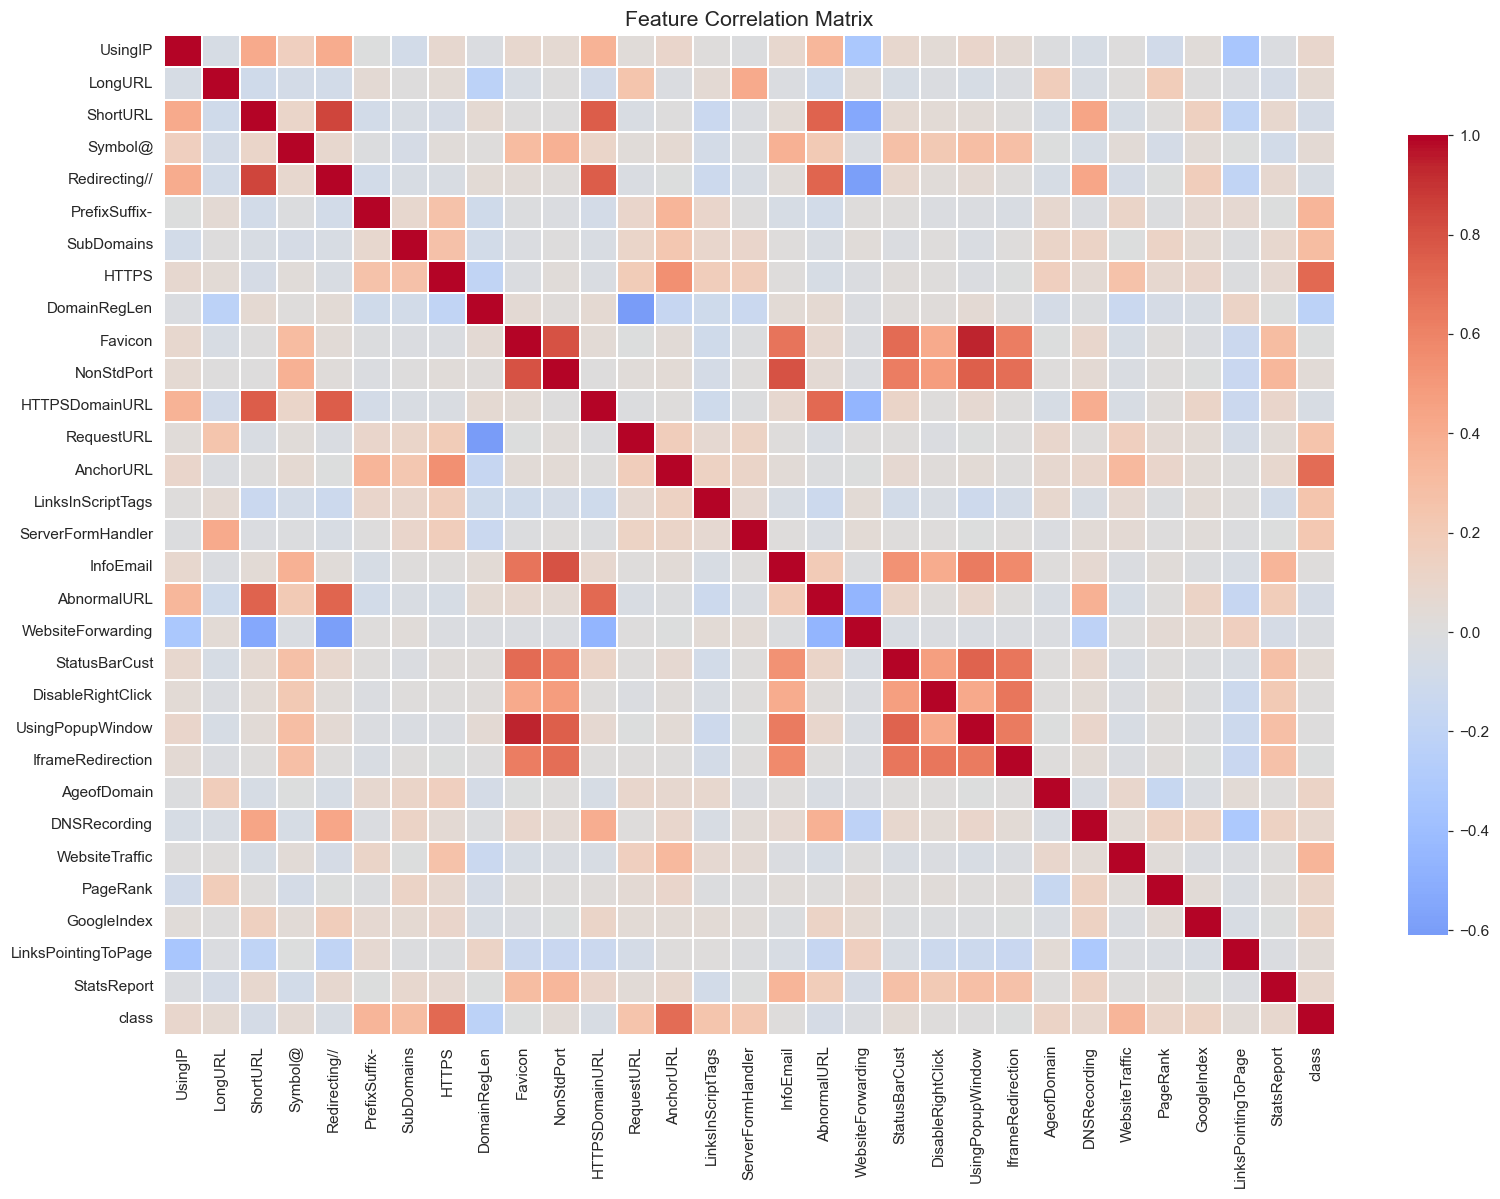

In [7]:
plt.figure(figsize=(15, 11))
sns.heatmap(df.corr(), cmap='coolwarm', center=0,
            linewidths=0.3, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Training   : {len(X_train)} samples')
print(f'Test       : {len(X_test)} samples')
print(f'Features   : {X.shape[1]}')

Training   : 7737 samples
Test       : 3317 samples
Features   : 30


In [9]:
models = {
    'Decision Tree'    : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'      : GaussianNB(),
    'Random Forest'    : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'              : SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Linear Regression': LinearRegression()
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f' {name} trained')

print('\nAll baseline models trained.')

 Decision Tree trained
 Naive Bayes trained
 Random Forest trained
 SVM trained
 Gradient Boosting trained
 Linear Regression trained

All baseline models trained.


In [10]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    if name == 'Linear Regression':
        y_pred = (y_pred > 0.5).astype(int)

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df.set_index('Model')

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Random Forest,0.9735,0.9701,0.9827,0.9763
Decision Tree,0.9602,0.9653,0.9632,0.9642
Gradient Boosting,0.9563,0.9532,0.9692,0.9611
SVM,0.9548,0.9511,0.9686,0.9598
Linear Regression,0.9295,0.9274,0.9475,0.9374
Naive Bayes,0.6030,0.9981,0.2879,0.4469


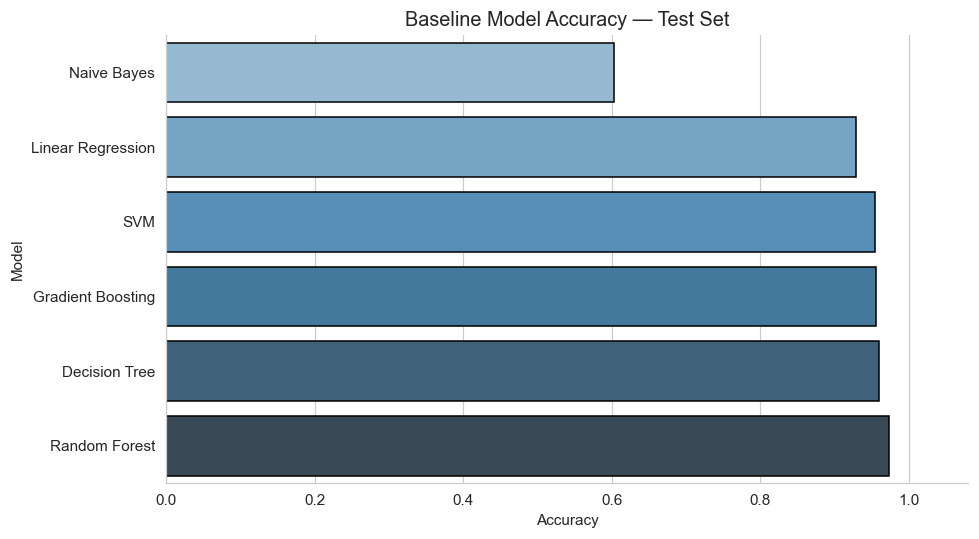

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values('Accuracy'),
            palette='Blues_d', edgecolor='black')
plt.title('Baseline Model Accuracy — Test Set', fontsize=13)
plt.xlabel('Accuracy')
plt.xlim(0, 1.08)
plt.tight_layout()
plt.show()

In [12]:
lr_h  = LogisticRegression(max_iter=5000, random_state=42)
svm_h = SVC(random_state=42)
dt_h  = DecisionTreeClassifier(random_state=42)

hard_voting = VotingClassifier(
    estimators=[('lr', lr_h), ('svm', svm_h), ('dt', dt_h)],
    voting='hard'
)
hard_voting.fit(X_train, y_train)
print('Hard Voting trained.')

Hard Voting trained.


In [13]:
lr_s  = LogisticRegression(max_iter=5000, random_state=42)
svm_s = SVC(probability=True, random_state=42)
dt_s  = DecisionTreeClassifier(random_state=42)

soft_voting = VotingClassifier(
    estimators=[('lr', lr_s), ('svm', svm_s), ('dt', dt_s)],
    voting='soft'
)
soft_voting.fit(X_train, y_train)
print('Soft Voting trained.')

Soft Voting trained.


In [14]:
for name, model in {'Hard Voting': hard_voting, 'Soft Voting': soft_voting}.items():
    y_pred = model.predict(X_test)
    print(f'--- {name} ---')
    print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

y_pred_soft = soft_voting.predict(X_test)

--- Hard Voting ---
Accuracy : 0.9566
              precision    recall  f1-score   support

  Legitimate       0.96      0.94      0.95      1469
    Phishing       0.95      0.97      0.96      1848

    accuracy                           0.96      3317
   macro avg       0.96      0.95      0.96      3317
weighted avg       0.96      0.96      0.96      3317

--- Soft Voting ---
Accuracy : 0.9674
              precision    recall  f1-score   support

  Legitimate       0.97      0.95      0.96      1469
    Phishing       0.96      0.98      0.97      1848

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317



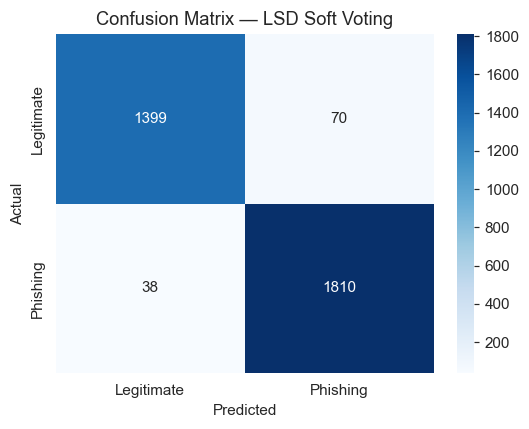

In [15]:
cm_soft = confusion_matrix(y_test, y_pred_soft)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix — LSD Soft Voting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

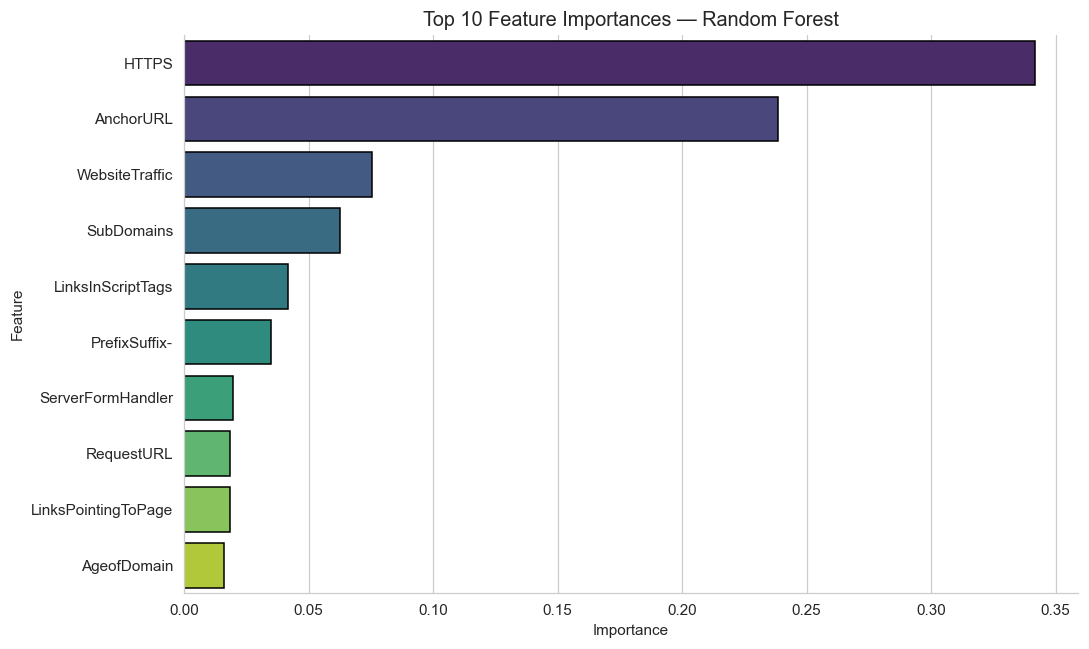

In [16]:
rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_full.fit(X, y)

fi_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(10),
            palette='viridis', edgecolor='black')
plt.title('Top 10 Feature Importances — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.2,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

xgb_acc  = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec  = recall_score(y_test, y_pred_xgb)
xgb_f1   = f1_score(y_test, y_pred_xgb)
xgb_auc  = roc_auc_score(y_test, y_prob_xgb)

print('XGBoost — Test Set')
print(f'  Accuracy  : {xgb_acc:.4f}')
print(f'  Precision : {xgb_prec:.4f}')
print(f'  Recall    : {xgb_rec:.4f}')
print(f'  F1        : {xgb_f1:.4f}')
print(f'  AUC-ROC   : {xgb_auc:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Phishing']))

XGBoost — Test Set
  Accuracy  : 0.9726
  Precision : 0.9695
  Recall    : 0.9816
  F1        : 0.9755
  AUC-ROC   : 0.9968

              precision    recall  f1-score   support

  Legitimate       0.98      0.96      0.97      1469
    Phishing       0.97      0.98      0.98      1848

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317



In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.2,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_xgb = cross_val_score(pipeline_xgb, X, y, cv=skf, scoring='accuracy')

print(f'XGBoost 10-Fold CV   Mean {cv_xgb.mean():.4f}   Std {cv_xgb.std():.4f}')

XGBoost 10-Fold CV   Mean 0.6925   Std 0.0133


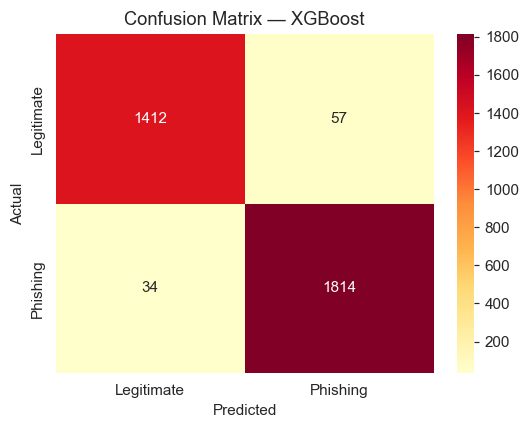

In [19]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [20]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.2,
    random_state=42,
    n_jobs=-1
)

lgbm_clf.fit(X_train, y_train)

y_pred_lgbm = lgbm_clf.predict(X_test)
y_prob_lgbm = lgbm_clf.predict_proba(X_test)[:, 1]

lgbm_acc  = accuracy_score(y_test, y_pred_lgbm)
lgbm_prec = precision_score(y_test, y_pred_lgbm)
lgbm_rec  = recall_score(y_test, y_pred_lgbm)
lgbm_f1   = f1_score(y_test, y_pred_lgbm)
lgbm_auc  = roc_auc_score(y_test, y_prob_lgbm)

print('LightGBM — Test Set')
print(f'  Accuracy  : {lgbm_acc:.4f}')
print(f'  Precision : {lgbm_prec:.4f}')
print(f'  Recall    : {lgbm_rec:.4f}')
print(f'  F1        : {lgbm_f1:.4f}')
print(f'  AUC-ROC   : {lgbm_auc:.4f}')
print()
print(classification_report(y_test, y_pred_lgbm, target_names=['Legitimate', 'Phishing']))

[LightGBM] [Info] Number of positive: 4309, number of negative: 3428
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 89
[LightGBM] [Info] Number of data points in the train set: 7737, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.556934 -> initscore=0.228729
[LightGBM] [Info] Start training from score 0.228729
LightGBM — Test Set
  Accuracy  : 0.9735
  Precision : 0.9706
  Recall    : 0.9821
  F1        : 0.9763
  AUC-ROC   : 0.9967

              precision    recall  f1-score   support

  Legitimate       0.98      0.96      0.97      1469
    Phishing       0.97      0.98      0.98      1848

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      33

In [21]:
from lightgbm import LGBMClassifier
pipeline_lgbm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.08,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.2,
        random_state=42,
        n_jobs=-1
    ))
])

cv_lgbm = cross_val_score(pipeline_lgbm, X, y, cv=skf, scoring='accuracy')

print(f'LightGBM 10-Fold CV   Mean {cv_lgbm.mean():.4f}   Std {cv_lgbm.std():.4f}')

[LightGBM] [Info] Number of positive: 5541, number of negative: 4407
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 9948, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.556996 -> initscore=0.228981
[LightGBM] [Info] Start training from score 0.228981
[LightGBM] [Info] Number of positive: 5541, number of negative: 4407
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 9948, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.556996 -> initscore=0.228981
[LightGBM] [Info] Start training from score 0.228981
[LightGBM] [Info] Number o

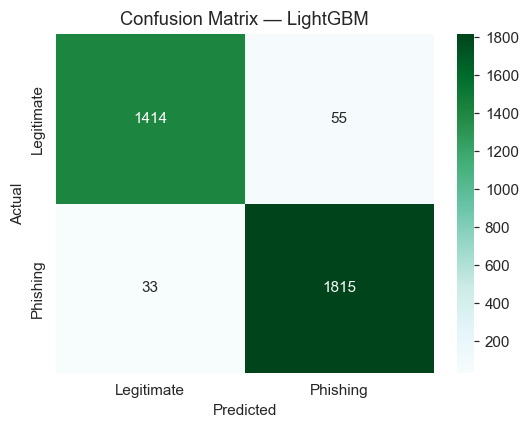

In [22]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix — LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
rf_model   = trained_models['Random Forest']
p_xgb      = xgb_clf.predict_proba(X_test)[:, 1]
p_lgbm     = lgbm_clf.predict_proba(X_test)[:, 1]
p_rf       = rf_model.predict_proba(X_test)[:, 1]

risk_score = 0.40 * p_xgb + 0.35 * p_lgbm + 0.25 * p_rf


def assign_tier(s):
    if s < 0.35:
        return 'Safe'
    elif s < 0.70:
        return 'Suspicious'
    return 'High Risk'


tier_labels = np.array([assign_tier(s) for s in risk_score])

risk_df = pd.DataFrame({
    'XGBoost_%'  : (p_xgb * 100).round(1),
    'LightGBM_%' : (p_lgbm * 100).round(1),
    'RF_%'       : (p_rf * 100).round(1),
    'RiskScore_%': (risk_score * 100).round(1),
    'Tier'       : tier_labels,
    'TrueLabel'  : ['Phishing' if v == 1 else 'Legitimate' for v in y_test.values]
})

print('Tier distribution:')
print(risk_df['Tier'].value_counts())
print()
risk_df.head(10)

Tier distribution:
Tier
High Risk     1803
Safe          1416
Suspicious      98
Name: count, dtype: int64



,XGBoost_%,LightGBM_%,RF_%,RiskScore_%,Tier,TrueLabel
0,0.000000,0.0,0.0,0.0,Safe,Legitimate
1,99.800003,100.0,100.0,99.9,High Risk,Phishing
2,99.900002,100.0,100.0,100.0,High Risk,Phishing
3,17.000000,19.1,19.1,18.2,Safe,Legitimate
4,12.000000,13.7,1.2,9.9,Safe,Legitimate
5,0.000000,0.0,0.0,0.0,Safe,Legitimate
6,0.200000,0.3,0.0,0.2,Safe,Legitimate
7,0.100000,0.1,0.0,0.0,Safe,Legitimate
8,67.300003,74.5,65.8,69.5,Suspicious,Legitimate
9,0.000000,0.0,0.0,0.0,Safe,Legitimate


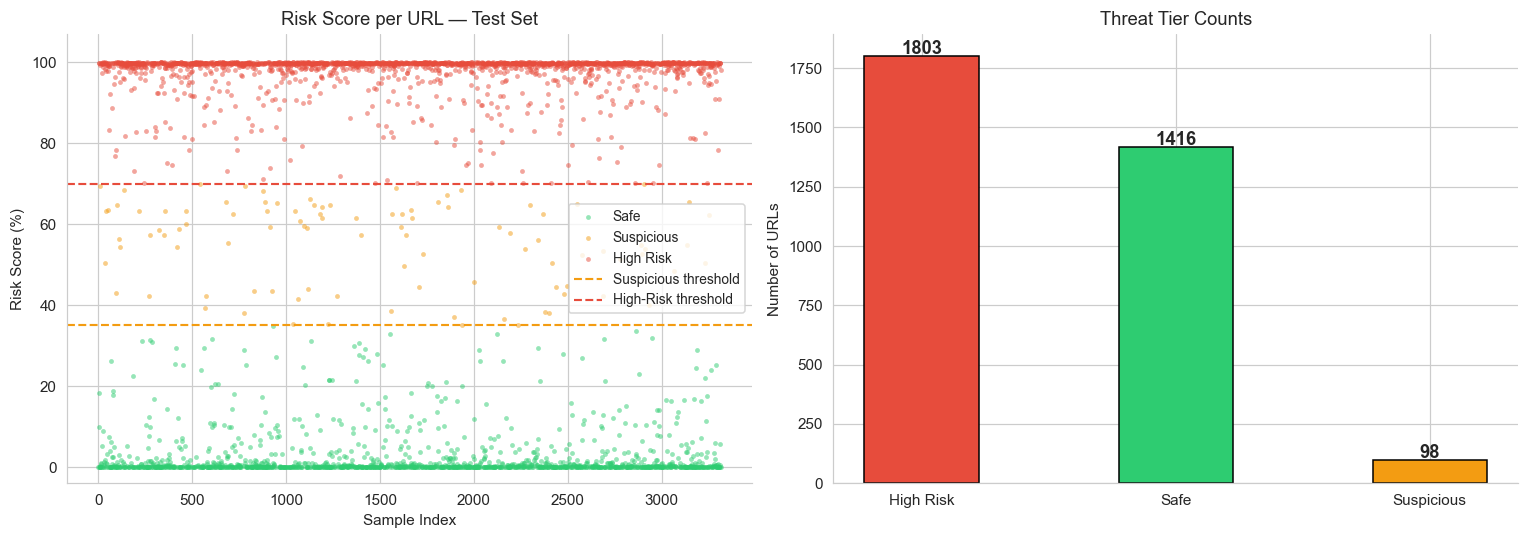

In [24]:
tier_col = {'Safe': '#2ecc71', 'Suspicious': '#f39c12', 'High Risk': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tier, col in tier_col.items():
    idx = np.where(tier_labels == tier)[0]
    axes[0].scatter(idx, risk_score[idx] * 100, c=col,
                    label=tier, alpha=0.5, s=10, linewidths=0)

axes[0].axhline(35, linestyle='--', color='#f39c12', linewidth=1.4, label='Suspicious threshold')
axes[0].axhline(70, linestyle='--', color='#e74c3c', linewidth=1.4, label='High-Risk threshold')
axes[0].set_ylim(-4, 107)
axes[0].set_title('Risk Score per URL — Test Set', fontsize=12)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Risk Score (%)')
axes[0].legend(fontsize=9)

tc   = risk_df['Tier'].value_counts()
bcol = [tier_col[t] for t in tc.index]
bars = axes[1].bar(tc.index, tc.values, color=bcol, edgecolor='black', width=0.45)
for bar, v in zip(bars, tc.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8, str(v),
                 ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Threat Tier Counts', fontsize=12)
axes[1].set_ylabel('Number of URLs')

plt.tight_layout()
plt.show()

In [25]:
y_pred_risk = (risk_score >= 0.50).astype(int)

risk_acc  = accuracy_score(y_test, y_pred_risk)
risk_prec = precision_score(y_test, y_pred_risk)
risk_rec  = recall_score(y_test, y_pred_risk)
risk_f1   = f1_score(y_test, y_pred_risk)
risk_auc  = roc_auc_score(y_test, risk_score)

print('Risk Score Ensemble — Test Set')
print(f'  Accuracy  : {risk_acc:.4f}')
print(f'  Precision : {risk_prec:.4f}')
print(f'  Recall    : {risk_rec:.4f}')
print(f'  F1        : {risk_f1:.4f}')
print(f'  AUC-ROC   : {risk_auc:.4f}')

Risk Score Ensemble — Test Set
  Accuracy  : 0.9750
  Precision : 0.9712
  Recall    : 0.9843
  F1        : 0.9777
  AUC-ROC   : 0.9973


In [26]:
perm = permutation_importance(
    xgb_clf, X_test, y_test,
    n_repeats=10, random_state=42, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Feature'         : X.columns,
    'Importance_Mean' : perm.importances_mean,
    'Importance_Std'  : perm.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

perm_df.head(12)

,Feature,Importance_Mean,Importance_Std
0,AnchorURL,0.132650,0.005041
1,HTTPS,0.103979,0.004095
2,WebsiteTraffic,0.021917,0.001897
3,PrefixSuffix-,0.020410,0.001868
4,SubDomains,0.014923,0.001509
5,LinksInScriptTags,0.014441,0.001289
6,LinksPointingToPage,0.011185,0.002006
7,UsingIP,0.009587,0.001536
8,ServerFormHandler,0.009436,0.001408
9,DNSRecording,0.007658,0.001466


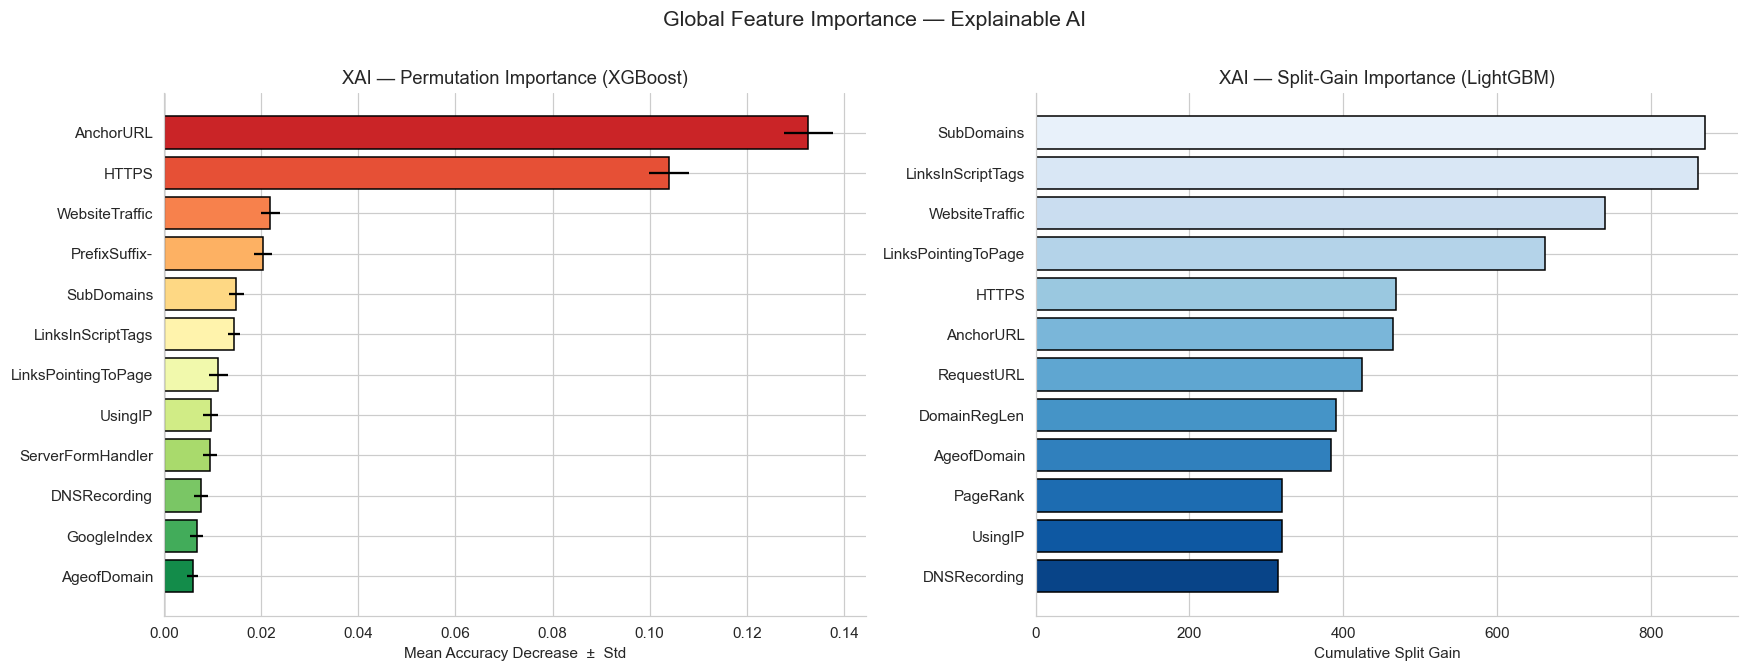

In [27]:
lgbm_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': lgbm_clf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_perm = perm_df.head(12)
axes[0].barh(
    top_perm['Feature'][::-1],
    top_perm['Importance_Mean'][::-1],
    xerr=top_perm['Importance_Std'][::-1],
    color=sns.color_palette('RdYlGn_r', 12),
    edgecolor='black'
)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('XAI — Permutation Importance (XGBoost)', fontsize=12)
axes[0].set_xlabel('Mean Accuracy Decrease  ±  Std')

top_lgbm = lgbm_imp.head(12)
axes[1].barh(
    top_lgbm['Feature'][::-1],
    top_lgbm['Importance'][::-1],
    color=sns.color_palette('Blues_r', 12),
    edgecolor='black'
)
axes[1].set_title('XAI — Split-Gain Importance (LightGBM)', fontsize=12)
axes[1].set_xlabel('Cumulative Split Gain')

plt.suptitle('Global Feature Importance — Explainable AI', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

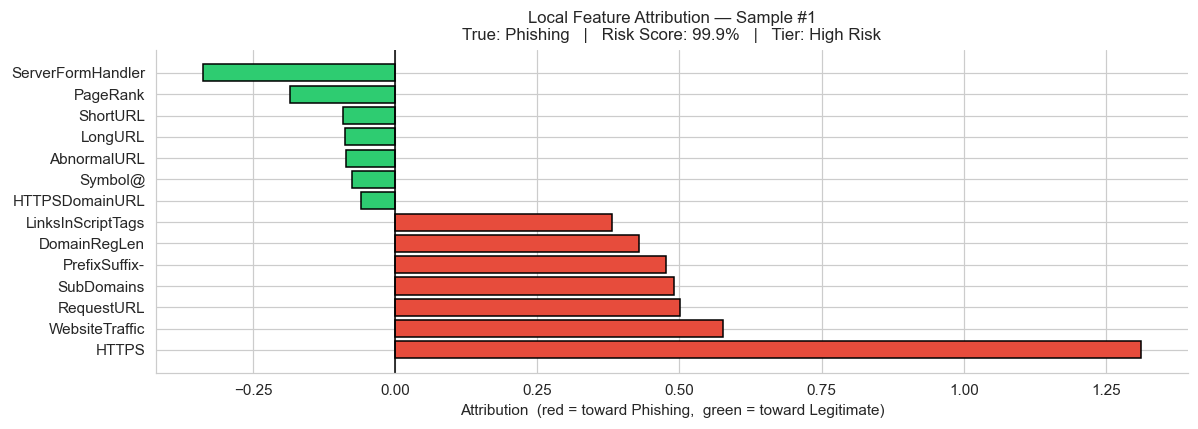

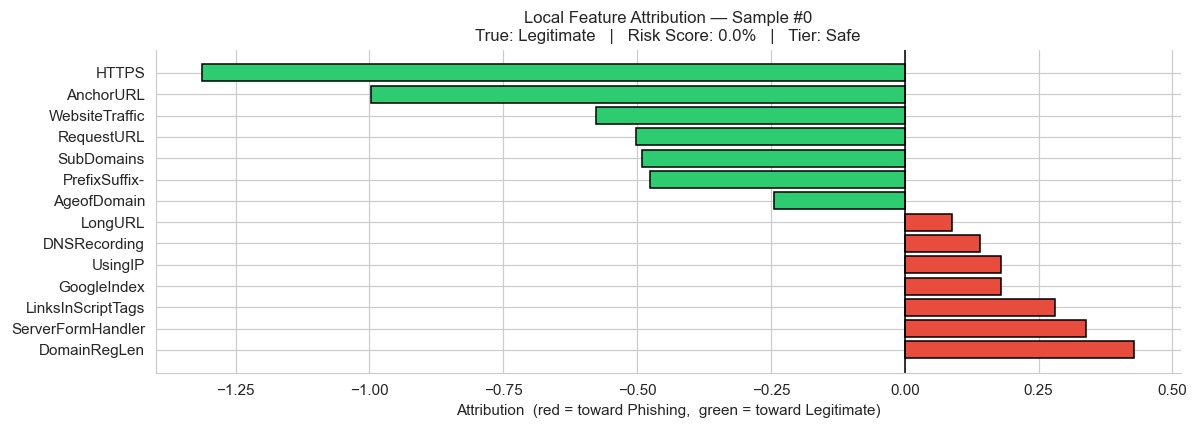

In [28]:
phishing_centroid = X[y == 1].mean()
legit_centroid    = X[y == 0].mean()


def explain_sample(sample_index, true_label):
    sample = X_test.iloc[sample_index]
    score  = risk_score[sample_index]
    tier   = assign_tier(score)

    attribution = pd.Series({
        feat: (abs(sample[feat] - legit_centroid[feat]) -
               abs(sample[feat] - phishing_centroid[feat]))
        for feat in X.columns
    }).sort_values(ascending=False)

    display_feats = pd.concat([attribution.head(7), attribution.tail(7)])
    bar_colors    = ['#e74c3c' if v > 0 else '#2ecc71' for v in display_feats.values]

    plt.figure(figsize=(11, 4))
    plt.barh(display_feats.index, display_feats.values,
             color=bar_colors, edgecolor='black')
    plt.axvline(0, color='black', linewidth=1)
    plt.title(
        f'Local Feature Attribution — Sample #{sample_index}\n'
        f'True: {true_label}   |   Risk Score: {score * 100:.1f}%   |   Tier: {tier}',
        fontsize=11
    )
    plt.xlabel('Attribution  (red = toward Phishing,  green = toward Legitimate)')
    plt.tight_layout()
    plt.show()


phish_idx = int(np.where(y_test.values == 1)[0][0])
legit_idx = int(np.where(y_test.values == 0)[0][0])

explain_sample(phish_idx, 'Phishing')
explain_sample(legit_idx, 'Legitimate')

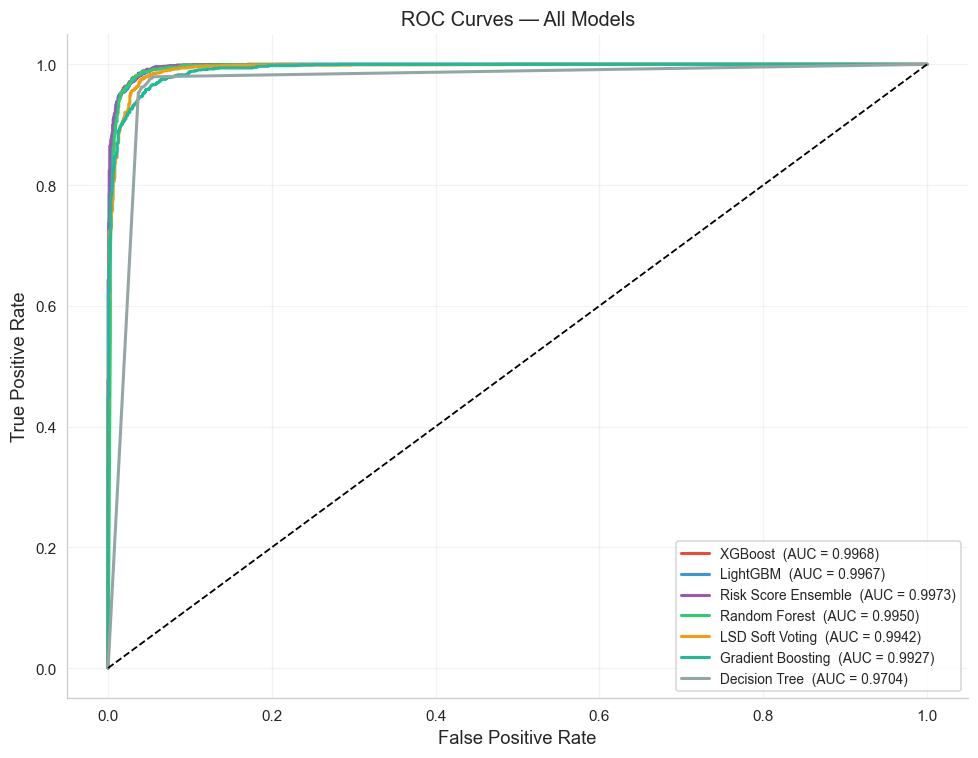

In [29]:
roc_suite = {
    'XGBoost'            : (xgb_clf,                             '#e74c3c'),
    'LightGBM'           : (lgbm_clf,                            '#3498db'),
    'Risk Score Ensemble': (None,                                '#9b59b6'),
    'Random Forest'      : (trained_models['Random Forest'],     '#2ecc71'),
    'LSD Soft Voting'    : (soft_voting,                         '#f39c12'),
    'Gradient Boosting'  : (trained_models['Gradient Boosting'], '#1abc9c'),
    'Decision Tree'      : (trained_models['Decision Tree'],     '#95a5a6'),
}

plt.figure(figsize=(9, 7))

for label, (model, color) in roc_suite.items():
    probs = risk_score if label == 'Risk Score Ensemble' else model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label}  (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend(fontsize=9, loc='lower right')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [30]:
all_results = results.copy()

y_pred_hard = hard_voting.predict(X_test)

for name, y_p in [('LSD Hard Voting', y_pred_hard), ('LSD Soft Voting', y_pred_soft)]:
    all_results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_p), 4),
        'Precision': round(precision_score(y_test, y_p), 4),
        'Recall'   : round(recall_score(y_test, y_p), 4),
        'F1 Score' : round(f1_score(y_test, y_p), 4)
    })

for name, acc, prec, rec, f1 in [
    ('XGBoost',             xgb_acc,  xgb_prec,  xgb_rec,  xgb_f1),
    ('LightGBM',            lgbm_acc, lgbm_prec, lgbm_rec, lgbm_f1),
    ('Risk Score Ensemble', risk_acc, risk_prec, risk_rec, risk_f1),
]:
    all_results.append({
        'Model': name, 'Accuracy': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1 Score': round(f1, 4)
    })

final_df = pd.DataFrame(all_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)


def is_novel_model(name):
    return any(k in str(name) for k in ['XGBoost', 'LightGBM', 'Risk Score Ensemble'])

def highlight(row):
    return (['background-color:#f39c12; color:#000; font-weight:bold'] * len(row)
            if is_novel_model(row['Model']) else [''] * len(row))


final_df.style.apply(highlight, axis=1).format({
    k: '{:.4f}' for k in ['Accuracy', 'Precision', 'Recall', 'F1 Score']
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Risk Score Ensemble,0.9750,0.9712,0.9843,0.9777
1,LightGBM,0.9735,0.9706,0.9821,0.9763
2,Random Forest,0.9735,0.9701,0.9827,0.9763
3,XGBoost,0.9726,0.9695,0.9816,0.9755
4,LSD Soft Voting,0.9674,0.9628,0.9794,0.9710
5,Decision Tree,0.9602,0.9653,0.9632,0.9642
6,LSD Hard Voting,0.9566,0.9527,0.9702,0.9614
7,Gradient Boosting,0.9563,0.9532,0.9692,0.9611
8,SVM,0.9548,0.9511,0.9686,0.9598
9,Linear Regression,0.9295,0.9274,0.9475,0.9374


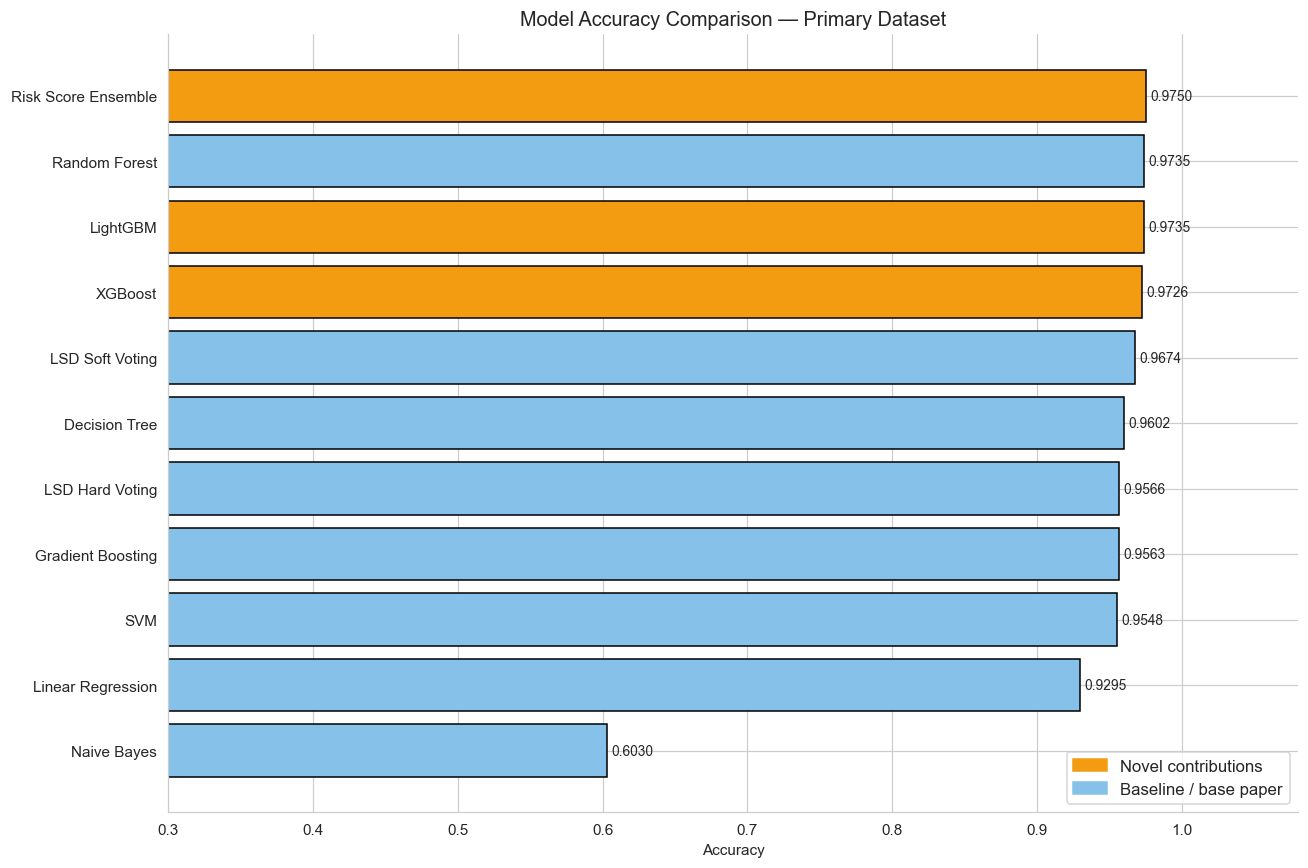

In [31]:
sorted_df  = final_df.sort_values('Accuracy')
def is_novel_model(name):
    return any(k in str(name) for k in ['XGBoost','LightGBM','Risk Score Ensemble'])
bar_colors = ['#f39c12' if is_novel_model(m) else '#85c1e9' for m in sorted_df['Model']]

plt.figure(figsize=(12, 8))
bars = plt.barh(sorted_df['Model'], sorted_df['Accuracy'],
                color=bar_colors, edgecolor='black')
for bar, val in zip(bars, sorted_df['Accuracy']):
    plt.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)

plt.legend(handles=[
    mpatches.Patch(color='#f39c12', label='Novel contributions'),
    mpatches.Patch(color='#85c1e9', label='Baseline / base paper')
], fontsize=11)
plt.title('Model Accuracy Comparison — Primary Dataset', fontsize=13)
plt.xlabel('Accuracy')
plt.xlim(0.3, 1.08)
plt.tight_layout()
plt.show()

In [ ]:
cv_suite = {
    'Decision Tree'    : DecisionTreeClassifier(random_state=42),
    'Random Forest'    : RandomForestClassifier(n_estimators=100, random_state=42),
    'LSD Soft Voting'  : soft_voting,
    'XGBoost'          : xgb_clf,
    'LightGBM'         : lgbm_clf,
}

cv_records = []
for name, model in cv_suite.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_records.append({'Model': name, 'CV Mean': scores.mean().round(4), 'CV Std': scores.std().round(4)})
    print(f'{name:<28}  Mean={scores.mean():.4f}   Std={scores.std():.4f}')

cv_df = pd.DataFrame(cv_records)

plt.figure(figsize=(9, 4))
def is_novel_model(name):
    return any(k in str(name) for k in ['XGBoost','LightGBM','Risk Score Ensemble'])
colors_cv = ['#f39c12' if is_novel_model(m) else '#85c1e9' for m in cv_df['Model']]
plt.barh(cv_df['Model'], cv_df['CV Mean'], xerr=cv_df['CV Std'],
         color=colors_cv, edgecolor='black', capsize=4)
plt.title('10-Fold Cross-Validation Accuracy', fontsize=13)
plt.xlabel('Mean Accuracy ± Std')
plt.xlim(0.85, 1.02)
plt.tight_layout()
plt.show()

Decision Tree                 Mean=0.9645   Std=0.0031
Random Forest                 Mean=0.9721   Std=0.0025


In [ ]:
import os

VAL_PATH = 'phishing_validation.csv'

if os.path.exists(VAL_PATH):
    val_raw = pd.read_csv(VAL_PATH)
    print(f'Loaded external validation file — shape: {val_raw.shape}')
    using_fallback = False
else:

    print('WARNING: phishing_validation.csv not found.')
    print('Using a 20% stratified hold-out of the primary dataset as a stand-in.\n')
    _, val_raw_X, _, val_raw_y = train_test_split(
        X, y, test_size=0.20, random_state=99, stratify=y
    )
    val_raw = val_raw_X.copy()
    val_raw['Result'] = val_raw_y.values   # use 'Result' so downstream code is identical
    using_fallback = True
    print(f'Stand-in validation set shape: {val_raw.shape}')

val_raw.head()

In [ ]:
print('Columns in validation dataset:')
print(val_raw.columns.tolist())

In [ ]:
CANDIDATE_TARGETS = ['Result', 'class', 'label', 'Label', 'target', 'Target', 'phishing']

target_val = None
for col in CANDIDATE_TARGETS:
    if col in val_raw.columns:
        target_val = col
        break

if target_val is None:

    two_val_cols = [c for c in val_raw.columns if val_raw[c].nunique() == 2]
    if two_val_cols:
        target_val = two_val_cols[-1]   # often the last column
        print(f'No standard target column found. Using "{target_val}" (only 2-valued column).')
    else:
        raise ValueError(
            'Cannot identify a target column in the validation CSV.\n'
            f'Columns present: {val_raw.columns.tolist()}\n'
            'Please rename your label column to "Result" and re-run.'
        )

print(f'Target column identified: "{target_val}"')

val_raw[target_val] = val_raw[target_val].replace(-1, 0)

for drop_col in ['Index', 'index', 'id', 'ID']:
    if drop_col in val_raw.columns and drop_col != target_val:
        val_raw = val_raw.drop(drop_col, axis=1)

print('Class balance in validation set:')
print(val_raw[target_val].value_counts())
print(f'\nNull values: {val_raw.isnull().sum().sum()}')

In [ ]:
shared = sorted(set(X.columns) & (set(val_raw.columns) - {target_val}))

print(f'Primary features    : {X.shape[1]}')
print(f'Validation features : {val_raw.shape[1] - 1}')
print(f'Shared features     : {len(shared)}')

if len(shared) == 0:
    raise ValueError(
        'No features overlap between the primary and validation datasets.\n'
        'Check that both CSVs use the same column names.'
    )

print()
print(shared)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = val_raw[target_val].value_counts()
axes[0].bar(['Legitimate', 'Phishing'], vc.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.45)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Validation Dataset — Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')

val_corr = val_raw[shared + [target_val]].corr()[target_val].abs().drop(target_val)
val_corr = val_corr.sort_values(ascending=False).head(12)
axes[1].barh(val_corr.index[::-1], val_corr.values[::-1], color='#9b59b6', edgecolor='black')
axes[1].set_title('Validation — Top Feature Correlations with Target', fontsize=12)
axes[1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

In [ ]:
X_train_s = X_train[shared]   # training set restricted to shared features
X_val     = val_raw[shared]
y_val     = val_raw[target_val]

xgb_v = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.08, max_depth=6,
    min_samples_leaf=20, l2_regularization=1.2, random_state=42
)
lgbm_v = ExtraTreesClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    max_features='sqrt', bootstrap=True, random_state=42, n_jobs=-1
)
rf_v = RandomForestClassifier(n_estimators=100, random_state=42)

xgb_v.fit(X_train_s, y_train)
lgbm_v.fit(X_train_s, y_train)
rf_v.fit(X_train_s, y_train)

print(f'Models retrained on {len(shared)} shared features.')

In [ ]:
vp_xgb  = xgb_v.predict_proba(X_val)[:, 1]
vp_lgbm = lgbm_v.predict_proba(X_val)[:, 1]
vp_rf   = rf_v.predict_proba(X_val)[:, 1]

val_risk = 0.40 * vp_xgb + 0.35 * vp_lgbm + 0.25 * vp_rf


def val_metrics(name, y_pred, proba=None):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_val, y_pred, zero_division=0), 4),
        'F1 Score' : round(f1_score(y_val, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_val, proba), 4) if proba is not None else '-'
    }


def is_novel_model(name):
    return any(k in str(name) for k in ['XGBoost','LightGBM','Risk Score Ensemble'])

val_res = [
    val_metrics('XGBoost',             (vp_xgb  >= 0.5).astype(int), vp_xgb),
    val_metrics('LightGBM',            (vp_lgbm >= 0.5).astype(int), vp_lgbm),
    val_metrics('Risk Score Ensemble', (val_risk >= 0.5).astype(int), val_risk),
    val_metrics('Random Forest',          rf_v.predict(X_val),          vp_rf),
    ]

for bname, bmodel in [
    ('Decision Tree',     DecisionTreeClassifier(random_state=42)),
    ('Naive Bayes',       GaussianNB()),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
]:
    bmodel.fit(X_train_s, y_train)
    bp = bmodel.predict_proba(X_val)[:, 1]
    val_res.append(val_metrics(bname, bmodel.predict(X_val), bp))

val_results_df = (
    pd.DataFrame(val_res)
    .sort_values('Accuracy', ascending=False)
    .reset_index(drop=True)
)

val_results_df.style.apply(
    lambda row: (['background-color:#f39c12; color:#000; font-weight:bold'] * len(row)
                 if is_novel_model(row['Model']) else [''] * len(row)),
    axis=1
)

In [ ]:
val_s  = val_results_df.sort_values('Accuracy')
def is_novel_model(name):
    return any(k in str(name) for k in ['XGBoost','LightGBM','Risk Score Ensemble'])
vcols  = ['#f39c12' if is_novel_model(m) else '#85c1e9' for m in val_s['Model']]

plt.figure(figsize=(11, 6))
bars = plt.barh(val_s['Model'], val_s['Accuracy'], color=vcols, edgecolor='black')
for bar, val in zip(bars, val_s['Accuracy']):
    plt.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)
plt.legend(handles=[
    mpatches.Patch(color='#f0c674', label='Novel contributions'),
    mpatches.Patch(color='#85c1e9', label='Baseline')
], fontsize=11)
title_suffix = '(Stand-in split)' if using_fallback else '(Kaggle Dataset)'
plt.title(f'Accuracy — External Validation {title_suffix}', fontsize=13)
plt.xlabel('Accuracy')
plt.xlim(0.3, 1.08)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds, cmap) in zip(axes, [
    ('XGBoost',             (vp_xgb  >= 0.5).astype(int), 'YlOrRd'),
    ('LightGBM',            (vp_lgbm >= 0.5).astype(int), 'BuGn'),
    ('Risk Score Ensemble', (val_risk >= 0.5).astype(int), 'Purples'),
]):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Legit', 'Phish'],
                yticklabels=['Legit', 'Phish'])
    ax.set_title(f'{name}\nAcc={accuracy_score(y_val, preds):.4f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — External Validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 7))

for label, proba, color in [
    ('XGBoost (Val)',             vp_xgb,   '#e74c3c'),
    ('LightGBM (Val)',            vp_lgbm,  '#3498db'),
    ('Risk Score Ensemble (Val)', val_risk, '#9b59b6'),
    ('Random Forest (Val)',       vp_rf,    '#2ecc71'),
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{label}  (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — External Validation Dataset', fontsize=13)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
primary_n = final_df[final_df['Model'].str.contains('XGBoost|LightGBM|Risk Score Ensemble')][['Model', 'Accuracy', 'F1 Score']].copy()
primary_n['Dataset'] = 'Primary (Test Split)'

val_n = val_results_df[val_results_df['Model'].str.contains('XGBoost|LightGBM|Risk Score Ensemble')][['Model', 'Accuracy', 'F1 Score']].copy()
val_n['Dataset'] = 'External Validation'

comparison = pd.concat([primary_n, val_n], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1 Score']):
    pivot = comparison.pivot(index='Model', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'],
               edgecolor='black', width=0.55)
    ax.set_title(f'{metric} — Primary vs Validation', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0.7, 1.06)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}',
                    (p.get_x() + p.get_width() / 2, p.get_height() + 0.003),
                    ha='center', fontsize=8)

plt.suptitle('Generalisation — Novel Models Across Both Datasets', fontsize=14)
plt.tight_layout()
plt.show()

print(comparison.to_string(index=False))